# Előfizetőszám-előrejelzés — kohorsz-alapú modell

**FONTOS:** a `data/subscriptions_PLACEHOLDER.csv` egyelőre teljesen
szintetikus (kézzel épített) adat, NEM valós, névtelenített
checkers.com-minta -- az utóbbi BigQuery-jóváhagyásra vár. A séma már a
végleges -- ha megjön a valós adat, ez a notebook változtatás nélkül tovább
fut.

Minden sor egy előfizető: `registration_cohort_month` (mikor lett előfizető,
relatív hónapindex), `tenure_months` (jelenlegi/teljes tartás), `is_active`
(még előfizető-e ma), `tier`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/subscriptions_PLACEHOLDER.csv")
CURRENT_MONTH = df["registration_cohort_month"].max()
df.head()

,subscriber_id,tier,monthly_price_usd,registration_cohort_month,tenure_months,is_active,upgraded,downgraded
0,0,Alap,9.57,0,0,False,False,False
1,1,Prémium,19.21,0,0,False,False,False
2,2,Alap,9.70,0,1,False,False,False
3,3,Alap,10.12,0,0,False,False,False
4,4,Prémium,19.46,0,3,False,False,True


## 1. Egy véletlen kohorsz kontra az átlag

Válasszunk egy véletlen regisztrációs kohorszot, és hasonlítsuk össze a saját
túlélési görbéjét az ÖSSZES kohorszra számolt (pooled) átlaggal.

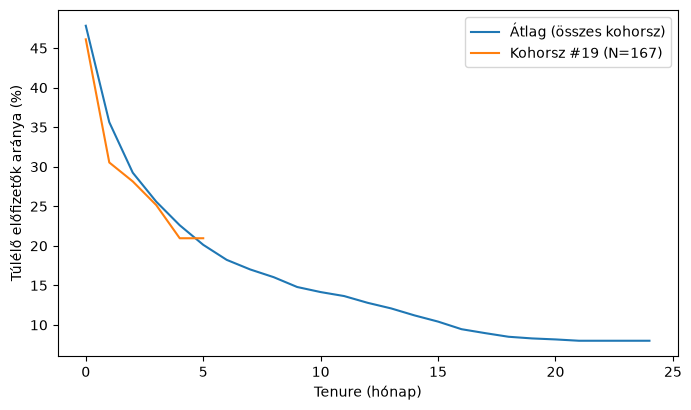

In [2]:
def life_table_survival(sub_df):
    max_t = sub_df["tenure_months"].max()
    haz = []
    for t in range(max_t + 1):
        at_risk = sub_df[sub_df["tenure_months"] >= t]
        events = sub_df[(sub_df["tenure_months"] == t) & (~sub_df["is_active"])]
        haz.append(len(events) / len(at_risk) if len(at_risk) else np.nan)
    haz = pd.Series(haz)
    return (1 - haz).cumprod()

pooled_survival = life_table_survival(df)

rng = np.random.default_rng(3)
random_cohort_month = rng.choice(df["registration_cohort_month"].unique())
cohort_df = df[df["registration_cohort_month"] == random_cohort_month]
cohort_survival = life_table_survival(cohort_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(pooled_survival.index, pooled_survival.values * 100, label="Átlag (összes kohorsz)")
ax.plot(cohort_survival.index, cohort_survival.values * 100, label=f"Kohorsz #{random_cohort_month} (N={len(cohort_df)})")
ax.set_xlabel("Tenure (hónap)")
ax.set_ylabel("Túlélő előfizetők aránya (%)")
ax.legend()
plt.show()

## 2. Az előfizetőszám = az élő kohorszok összege

Ma (`CURRENT_MONTH`) minden kohorsznak más a "kora" (tenure-je) — a
legrégebbi kohorsz messze van már az első hónapok gyors lemorzsolódásától, a
legfrissebb még alig indult. A teljes előfizetőszám ma egyszerűen: **minden
kohorszból ma még aktívak összege.**

Aktív előfizetők ma (CURRENT_MONTH=23): 560


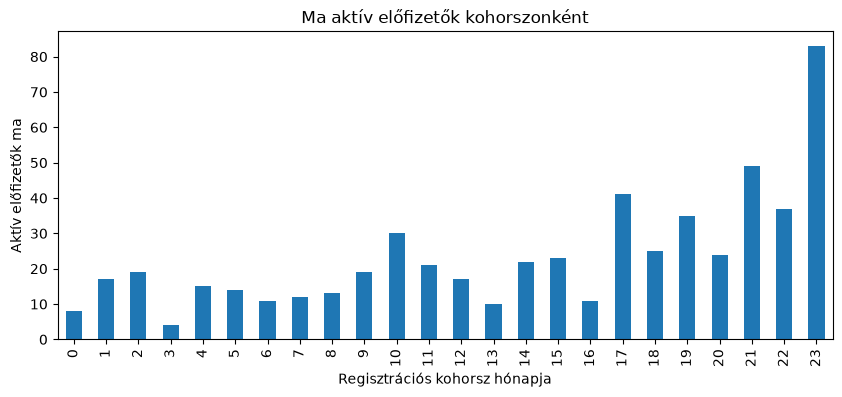

In [3]:
total_active_today = df["is_active"].sum()
print(f"Aktív előfizetők ma (CURRENT_MONTH={CURRENT_MONTH}): {total_active_today}")

by_cohort_today = df.groupby("registration_cohort_month")["is_active"].sum()
by_cohort_today.plot(kind="bar", figsize=(10, 4), title="Ma aktív előfizetők kohorszonként")
plt.xlabel("Regisztrációs kohorsz hónapja")
plt.ylabel("Aktív előfizetők ma")
plt.show()

## 3. Előrejelzés: hányan lesznek aktívak 6 hónappal később?

Minden kohorsz 6 hónappal öregebb lesz. A pooled túlélési görbe segítségével
kiszámolhatjuk a **feltételes túlélési valószínűséget**: ha valaki már
eljutott a mai koráig, mekkora eséllyel él túl még 6 hónapot?

$$P(\text{túlél még 6 hónapot} \mid \text{már túlélt } t \text{ hónapot}) = \frac{S(t+6)}{S(t)}$$

Ezt minden kohorszra alkalmazva, és összegezve, megkapjuk a **teljes
előfizetőszám-előrejelzést** 6 hónappal előre.

In [4]:
HORIZON = 6

def extrapolate_survival(pooled_survival, t):
    """Ha t tullepne a pooled gorbe megfigyelt tartomanyan, az utolso
    (leglassabb, floor-kozeli) hazard-ertekkel toltjuk ki -- ez egy explicit,
    cimkezett felteves, nem az adatbol szarmazo teny."""
    max_observed = pooled_survival.index.max()
    if t <= max_observed:
        return pooled_survival.loc[t]
    tail_hazard = 1 - (pooled_survival.iloc[-1] / pooled_survival.iloc[-2])
    extra_periods = t - max_observed
    return pooled_survival.iloc[-1] * (1 - tail_hazard) ** extra_periods

forecast_rows = []
for cohort_month, g in df.groupby("registration_cohort_month"):
    current_age = CURRENT_MONTH - cohort_month
    future_age = current_age + HORIZON
    active_today = g["is_active"].sum()

    s_now = extrapolate_survival(pooled_survival, current_age)
    s_future = extrapolate_survival(pooled_survival, future_age)
    conditional_survival = s_future / s_now if s_now > 0 else 0.0

    forecast_rows.append(
        {
            "registration_cohort_month": cohort_month,
            "active_today": active_today,
            "conditional_survival_6mo": conditional_survival,
            "forecast_active_in_6mo": active_today * conditional_survival,
        }
    )

forecast_df = pd.DataFrame(forecast_rows)
total_today = forecast_df["active_today"].sum()
total_forecast = forecast_df["forecast_active_in_6mo"].sum()

print(f"Aktív előfizetők ma: {total_today:.0f}")
print(f"Előrejelzett aktív előfizetők {HORIZON} hónap múlva: {total_forecast:.0f}")
print(f"Változás: {total_forecast / total_today - 1:.2%}")
print()
print("(Megjegyzés: ez a szám csak a MEGLÉVŐ kohorszok lemorzsolódását vetíti előre --")
print("nem tartalmaz ÚJ regisztrációkból konvertáló friss kohorszokat. Az a következő lépés.)")

Aktív előfizetők ma: 560
Előrejelzett aktív előfizetők 6 hónap múlva: 369
Változás: -34.14%

(Megjegyzés: ez a szám csak a MEGLÉVŐ kohorszok lemorzsolódását vetíti előre --
nem tartalmaz ÚJ regisztrációkból konvertáló friss kohorszokat. Az a következő lépés.)


## Ti jöttök

A fenti előrejelzés **nem** tartalmazza az új, jövőben regisztráló és
konvertáló felhasználókból induló friss kohorszokat -- csak a MA MEGLÉVŐ
előfizetők további lemorzsolódását vetíti előre.

Ha feltesszük, hogy minden hónapban **150 új előfizető** csatlakozik (egy
teljesen új, nulla tenure-ű mini-kohorsz formájában), és ők is a pooled
túlélési görbe szerint morzsolódnak -- mennyi lesz az előfizetőszám 6 hónap
múlva, ha ezt is hozzáadjuk?

In [5]:
new_subscribers_per_month = 150

new_cohort_contribution = 0.0
for months_since_join in range(1, HORIZON + 1):
    s = extrapolate_survival(pooled_survival, months_since_join)
    new_cohort_contribution += new_subscribers_per_month * s

total_with_new_cohorts = total_forecast + new_cohort_contribution
print(f"Meglévő kohorszokból 6 hónap múlva: {total_forecast:.0f}")
print(f"+ új kohorszok hozzájárulása: {new_cohort_contribution:.0f}")
print(f"= Teljes előrejelzett előfizetőszám 6 hónap múlva: {total_with_new_cohorts:.0f}")

Meglévő kohorszokból 6 hónap múlva: 369
+ új kohorszok hozzájárulása: 227
= Teljes előrejelzett előfizetőszám 6 hónap múlva: 596
